In [ ]:
# STEP 0: Import all the libraries we need


import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from PIL import Image              # helps us open and resize images

print('All libraries imported successfully!')
print('TensorFlow version:', tf.__version__)

All libraries imported successfully!
TensorFlow version: 2.19.0


In [ ]:
# STEP 1: Unzip the Dataset


import zipfile
import os

# Path to your zip file in Colab's local storage
zip_path = '/content/Copy of devnagari digit.zip'

# Unzip into /content/ folder
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')

print('Dataset unzipped successfully!')

# Optional: See what was extracted
for root, dirs, files in os.walk('/content/'):
    # Skip system folders
    if any(skip in root for skip in ['.config', 'sample_data', 'drive']):
        continue
    level = root.replace('/content/', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')

Dataset unzipped successfully!
/
DevanagariHandwrittenDigitDataset/
  Train/
    digit_9/
    digit_8/
    digit_6/
    digit_7/
    digit_4/
    digit_1/
    digit_0/
    digit_2/
    digit_5/
    digit_3/
  Test/
    digit_9/
    digit_8/
    digit_6/
    digit_7/
    digit_4/
    digit_1/
    digit_0/
    digit_2/
    digit_5/
    digit_3/


In [ ]:
# This should print ['Train', 'Test']
print('Inside DevanagariHandwrittenDigitDataset:')
print(os.listdir('/content/DevanagariHandwrittenDigitDataset/'))

# This should print ['digit_0', 'digit_1', ..., 'digit_9']
print('\nInside Train folder:')
print(os.listdir('/content/DevanagariHandwrittenDigitDataset/Train/'))

Inside DevanagariHandwrittenDigitDataset:
['Train', 'Test']

Inside Train folder:
['digit_9', 'digit_8', 'digit_6', 'digit_7', 'digit_4', 'digit_1', 'digit_0', 'digit_2', 'digit_5', 'digit_3']


In [ ]:
# ============================================================
# TASK 1: Load and Preprocess the Dataset
# ============================================================

# These are the paths to our Train and Test folders
train_dir = '/content/DevanagariHandwrittenDigitDataset/Train/'
test_dir  = '/content/DevanagariHandwrittenDigitDataset/Test/'

# All images will be resized to 28x28 pixels
IMG_HEIGHT = 28
IMG_WIDTH  = 28

# Number of digit classes (0 to 9)
NUM_CLASSES = 10


def load_images_from_folder(folder):
    # This function reads all images from a folder
    # and returns them as numbers (arrays) along with their labels

    images = []   # will store pixel data of each image
    labels = []   # will store the digit label for each image

    # Get sorted list of subfolders: ['digit_0', 'digit_1', ...]
    class_names = sorted(os.listdir(folder))

    # Map folder name to a number: {'digit_0': 0, 'digit_1': 1, ...}
    class_map = {name: i for i, name in enumerate(class_names)}

    print('Loading from:', folder)
    print('Classes found:', class_names)

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            try:
                # Open image and convert to grayscale (black and white)
                img = Image.open(img_path).convert('L')

                # Resize to 28x28
                img = img.resize((IMG_WIDTH, IMG_HEIGHT))

                # Convert to array and scale pixel values from 0-255 to 0-1
                img_array = np.array(img) / 255.0

                images.append(img_array)
                labels.append(label)

            except Exception as e:
                print('Skipping file:', img_path, '| Reason:', e)

    return np.array(images), np.array(labels)


# Load training images and labels
x_train_raw, y_train_raw = load_images_from_folder(train_dir)

# Load test images and labels
x_test_raw, y_test_raw = load_images_from_folder(test_dir)

print('\nTraining images shape:', x_train_raw.shape)
print('Test images shape    :', x_test_raw.shape)

Loading from: /content/DevanagariHandwrittenDigitDataset/Train/
Classes found: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
Loading from: /content/DevanagariHandwrittenDigitDataset/Test/
Classes found: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']

Training images shape: (17000, 28, 28)
Test images shape    : (3000, 28, 28)


In [ ]:
# ============================================================
# TASK 1 continued: Prepare Data for Keras
# ============================================================

# Flatten each 28x28 image into a single row of 784 numbers
# because Dense layers expect 1D input, not a 2D grid
# -1 means 'figure out the number of images automatically'
x_train = x_train_raw.reshape(-1, IMG_HEIGHT * IMG_WIDTH)  # shape: (num_images, 784)
x_test  = x_test_raw.reshape(-1, IMG_HEIGHT * IMG_WIDTH)

# One-hot encode the labels
# Example: digit 3 becomes [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
# This is required because we use categorical_crossentropy as the loss
y_train = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  num_classes=NUM_CLASSES)

print('x_train shape:', x_train.shape, '← (num_images, 784 pixels)')
print('y_train shape:', y_train.shape, '← (num_images, 10 classes)')
print('x_test shape :', x_test.shape)
print('y_test shape :', y_test.shape)

x_train shape: (17000, 784) ← (num_images, 784 pixels)
y_train shape: (17000, 10) ← (num_images, 10 classes)
x_test shape : (3000, 784)
y_test shape : (3000, 10)


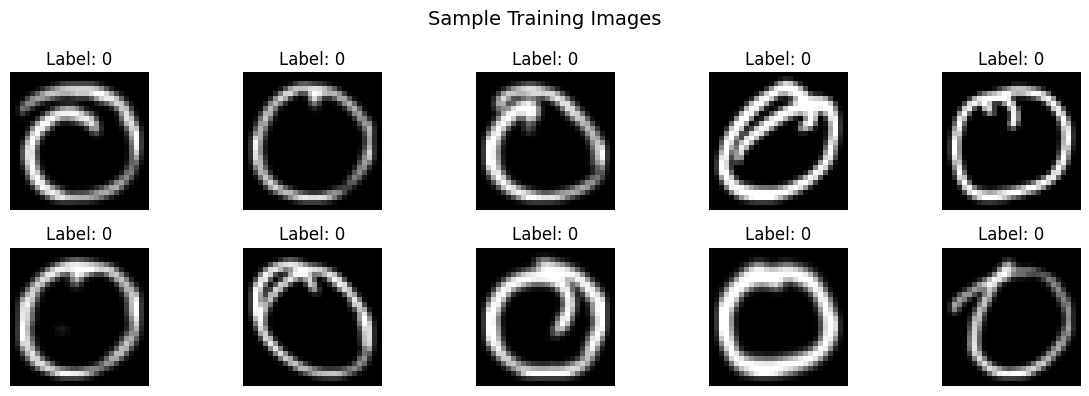

In [ ]:
# ============================================================
# TASK 1 continued: Show Sample Images
# ============================================================

plt.figure(figsize=(12, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    # Reshape from 784 back to 28x28 just for display
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')

    # np.argmax converts one-hot label back to a single digit number
    plt.title('Label: ' + str(np.argmax(y_train[i])))
    plt.axis('off')

plt.suptitle('Sample Training Images', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# TASK 2: Build the Fully Connected Neural Network
# ============================================================

# Sequential means we stack layers one after another
model = Sequential([

    # 1st hidden layer: 64 neurons, relu activation
    # input_shape tells Keras each image is 784 numbers long
    Dense(64, activation='relu', input_shape=(784,), name='hidden_layer_1'),

    # 2nd hidden layer: 128 neurons
    Dense(128, activation='relu', name='hidden_layer_2'),

    # 3rd hidden layer: 256 neurons
    Dense(256, activation='relu', name='hidden_layer_3'),

    # Output layer: 10 neurons (one per digit 0-9)
    # softmax converts raw scores into probabilities that add up to 1.0
    Dense(NUM_CLASSES, activation='softmax', name='output_layer')

])

# Print the model structure so we can see all layers
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# TASK 3: Compile the Model
# ============================================================

# Compiling sets up 3 things before training:
# optimizer  → how the model updates itself to get better
# loss       → how the model measures how wrong it is
# metrics    → what we want to track (accuracy)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Model compiled successfully!')
print('Optimizer : Adam')
print('Loss      : Categorical Crossentropy')
print('Metric    : Accuracy')

Model compiled successfully!
Optimizer : Adam
Loss      : Categorical Crossentropy
Metric    : Accuracy


In [ ]:
# ============================================================
# TASK 4: Train the Model
# ============================================================

BATCH_SIZE = 128   # model looks at 128 images at once before updating
EPOCHS     = 20    # model goes through the full dataset 20 times

# Callbacks are automatic actions that happen during training
callbacks = [

    # Saves the model every time validation accuracy improves
    keras.callbacks.ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    # Stops training early if validation loss stops improving
    # patience=5 means: stop if no improvement for 5 epochs in a row
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

print('Starting training...\n')

history = model.fit(
    x_train,            # training images
    y_train,            # training labels
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,   # use 20% of training data to check progress
    callbacks=callbacks,
    verbose=1
)

print('\nTraining complete!')

Starting training...

Epoch 1/20
104/107 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7058 - loss: 0.9940
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8484 - loss: 0.5031 - val_accuracy: 0.0000e+00 - val_loss: 16.4906
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9502 - loss: 0.1511
Epoch 2: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9564 - loss: 0.1413 - val_accuracy: 0.0000e+00 - val_loss: 16.6787
Epoch 3/20
 98/107 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9741 - loss: 0.0890
Epoch 3: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9737 - loss: 0.0863 - val_accuracy: 0.0000e+00 - val_loss: 17.0460
Epoch 4/20
105/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9835 - loss: 0.0564
Epoch 4: val_accuracy did 

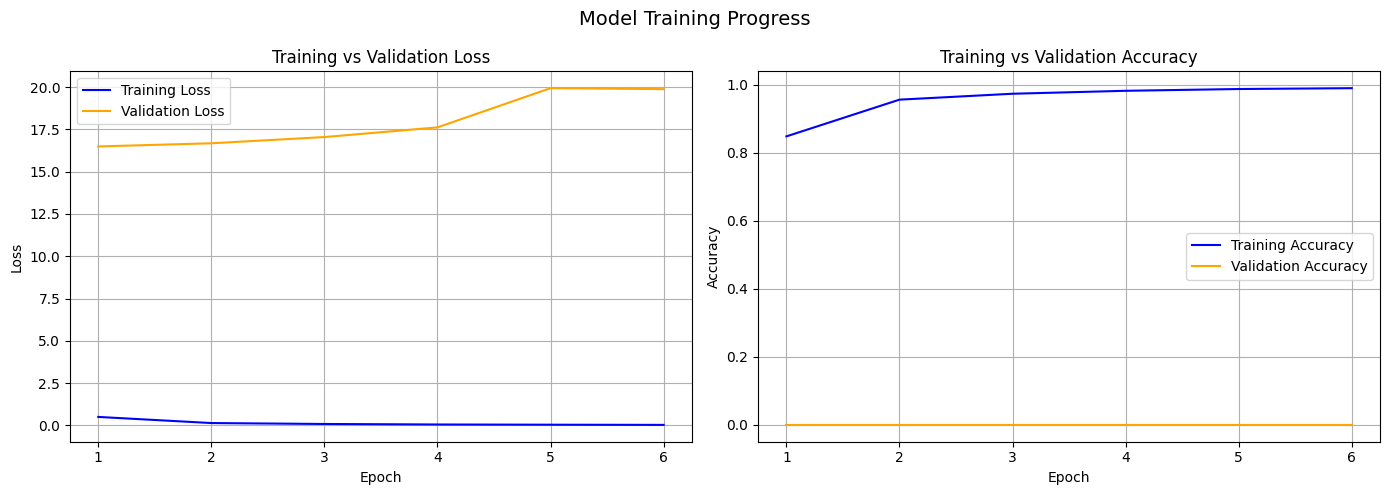

In [ ]:
# ============================================================
# TASK 4 continued: Plot Training Progress
# ============================================================

# Pull out the recorded values from training
train_loss = history.history['loss']
val_loss   = history.history['val_loss']
train_acc  = history.history['accuracy']
val_acc    = history.history['val_accuracy']

# x axis = epoch numbers
epochs_range = range(1, len(train_loss) + 1)

plt.figure(figsize=(14, 5))

# Left graph: Loss (lower is better)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss, label='Training Loss',   color='blue')
plt.plot(epochs_range, val_loss,   label='Validation Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

# Right graph: Accuracy (higher is better)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc, label='Training Accuracy',   color='blue')
plt.plot(epochs_range, val_acc,   label='Validation Accuracy', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

plt.suptitle('Model Training Progress', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# TASK 5: Evaluate the Model on Test Data
# ============================================================

# evaluate() runs the model on test images it has never seen before
# and tells us the loss and accuracy
print('Evaluating model on test data...\n')

test_loss, test_accuracy = model.evaluate(
    x_test,   # test images
    y_test,   # test labels
    verbose=2
)

print('\nTest Loss     :', round(test_loss, 4))
print('Test Accuracy :', round(test_accuracy * 100, 2), '%')

Evaluating model on test data...

94/94 - 0s - 2ms/step - accuracy: 0.7440 - loss: 3.4329

Test Loss     : 3.4329
Test Accuracy : 74.4 %


In [ ]:
# ============================================================
# TASK 6: Save the Model
# ============================================================

# Save the full model (architecture + weights) to a file
# so we can reload it later without retraining
save_path = 'devnagari_fcn_model.h5'
model.save(save_path)

print('Model saved to:', save_path)

Model saved to: devnagari_fcn_model.h5


In [ ]:
# ============================================================
# TASK 6: Save the Model
# ============================================================

# Save the full model (architecture + weights) to a file
# so we can reload it later without retraining
save_path = 'devnagari_fcn_model.h5'
model.save(save_path)

print('Model saved to:', save_path)

Model saved to: devnagari_fcn_model.h5


In [ ]:
# ============================================================
# TASK 7: Make Predictions on Test Images
# ============================================================

# predict() returns a probability for each of the 10 digit classes
# for every image in x_test
predictions = model.predict(x_test, verbose=0)

# np.argmax picks the digit with the highest probability
# that becomes our predicted label
predicted_labels = np.argmax(predictions, axis=1)

# Convert one-hot encoded y_test back to single digit numbers
true_labels = np.argmax(y_test, axis=1)

# Print predictions for the first 10 images
print('Predictions for first 10 test images:')
print(f"{'Index':<8} {'True Label':<14} {'Predicted':<14} {'Correct?'}")
print('-' * 48)
for i in range(10):
    correct = 'YES' if predicted_labels[i] == true_labels[i] else 'NO'
    print(f"{i:<8} {true_labels[i]:<14} {predicted_labels[i]:<14} {correct}")

Predictions for first 10 test images:
Index    True Label     Predicted      Correct?
------------------------------------------------
0        0              0              YES
1        0              4              NO
2        0              0              YES
3        0              0              YES
4        0              0              YES
5        0              0              YES
6        0              0              YES
7        0              0              YES
8        0              0              YES
9        0              0              YES


In [ ]:
# ============================================================
# TASK 7 continued: Show Probability Bars for One Image
# ============================================================

# predictions[0] is a list of 10 probabilities for the first test image
# for example: [0.02, 0.01, 0.03, 0.87, 0.01, ...]
# the highest value = the model's best guess

print('Raw probabilities for the first test image:')
print('(longer bar = more confident that it is that digit)\n')

for digit, prob in enumerate(predictions[0]):
    # create a visual bar — more probability = more blocks
    bar = '█' * int(prob * 30)
    print(f'  Digit {digit}: {prob:.4f}  {bar}')

print('\nModel predicted digit:', predicted_labels[0])
print('Actual digit was     :', true_labels[0])

Raw probabilities for the first test image:
(longer bar = more confident that it is that digit)

  Digit 0: 0.9603  ████████████████████████████
  Digit 1: 0.0022  
  Digit 2: 0.0009  
  Digit 3: 0.0005  
  Digit 4: 0.0022  
  Digit 5: 0.0002  
  Digit 6: 0.0013  
  Digit 7: 0.0324  
  Digit 8: 0.0000  
  Digit 9: 0.0000  

Model predicted digit: 0
Actual digit was     : 0


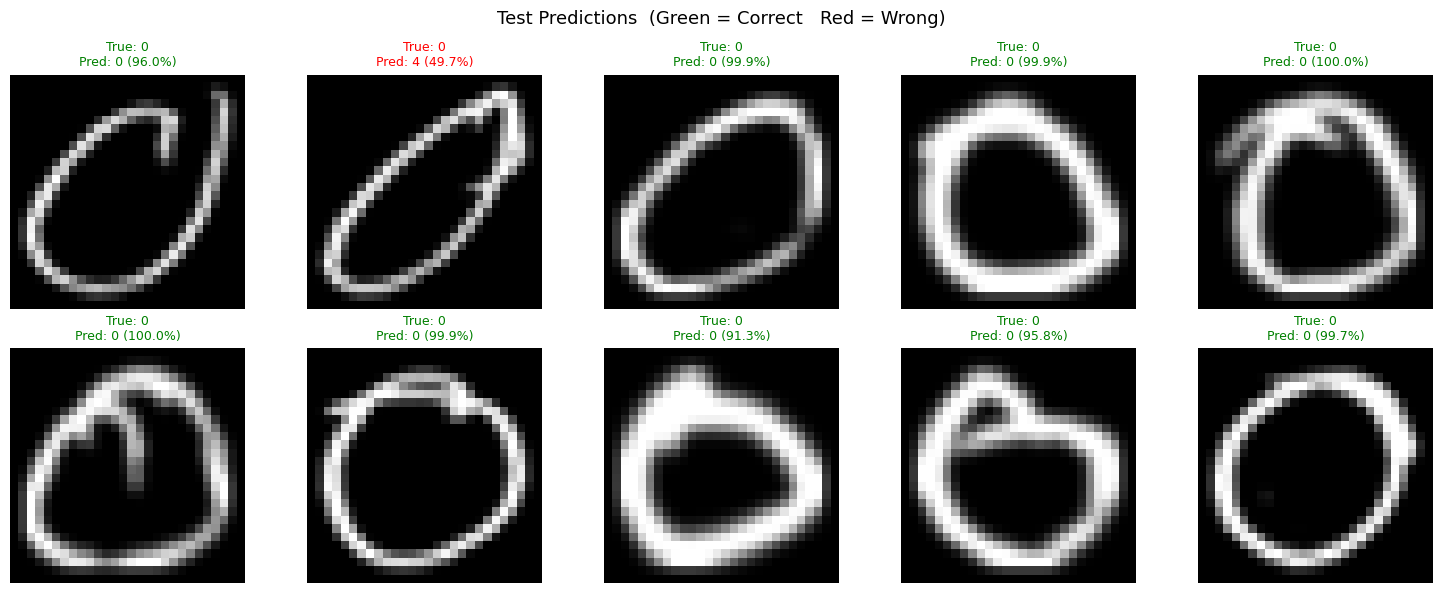

Overall: 2232 / 3000 correct = 74.4 % accuracy


In [ ]:
# ============================================================
# TASK 7 continued: Visualize Predictions on 10 Test Images
# ============================================================

# Green title = correct prediction
# Red title   = wrong prediction

plt.figure(figsize=(15, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    # Show the image
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')

    true_label = true_labels[i]
    pred_label = predicted_labels[i]

    # Confidence = probability of the predicted digit x 100
    confidence = predictions[i][pred_label] * 100

    # Green if correct, red if wrong
    color = 'green' if pred_label == true_label else 'red'

    plt.title(
        'True: ' + str(true_label) + '\nPred: ' + str(pred_label) + ' (' + str(round(confidence, 1)) + '%)',
        color=color,
        fontsize=9
    )
    plt.axis('off')

plt.suptitle('Test Predictions  (Green = Correct   Red = Wrong)', fontsize=13)
plt.tight_layout()
plt.show()

# Final overall accuracy
num_correct = np.sum(predicted_labels == true_labels)
num_total   = len(true_labels)
print('Overall:', num_correct, '/', num_total, 'correct =', round(num_correct / num_total * 100, 2), '% accuracy')